## Imports & Config

In [38]:
import os, gc, warnings, multiprocessing, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, precision_score, recall_score

from dataset import ClothingDataset

warnings.filterwarnings('ignore')
multiprocessing.set_start_method('spawn', force=True)

In [19]:
_vars = ['model', 'optimizer', 'scheduler', 'scaler', 'criterion',
         'train_loader', 'val_loader', 'test_loader',
         'train_dataset', 'val_dataset', 'test_dataset']
for _v in _vars:
    if _v in globals():
        del globals()[_v]
gc.collect()

if not torch.cuda.is_available():
    print('No CUDA device found — running on CPU.')
else:
    try:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        torch.cuda.reset_peak_memory_stats()
        free, total = torch.cuda.mem_get_info()
        print(f'VRAM free: {free/1024**3:.1f} GB / {total/1024**3:.1f} GB')
    except Exception as e:
        print(f'[!] CUDA context is broken: {e}')
        print('    → Go to Kernel → Restart & Clear Output, then re-run from the top.\n')
        result = subprocess.run(
            ['nvidia-smi', '--query-compute-apps=pid,used_memory,name', '--format=csv,noheader'],
            capture_output=True, text=True,
        )
        if result.stdout.strip():
            print('Processes currently holding VRAM:')
            print(result.stdout)

VRAM free: 7.4 GB / 7.6 GB


In [20]:
CONFIG = {
    'train_images_dir':  'images/train_224',
    'test_images_dir':   'images/test_224',
    'train_csv':         'images/train_labels.csv',
    'test_csv':          'images/test_labels.csv',
    'checkpoint_path':   'checkpoints/best_model.pth',

    'model_name':        'convnextv2_base',
    'num_classes':       25,

    'batch_size':        16,
    'num_workers':       4,
    'mixup_alpha':       0.2,

    'stage1_max_epochs': 40,
    'stage2_max_epochs': 80,
    'patience':          8,
    'min_delta':         5e-4,

    'threshold':         0.5,
    'lr_head':           1e-3,
    'lr_backbone':       1e-5,
    'weight_decay':      1e-4,
    'grad_clip':         1.0,
    'pos_weight_cap':    10.0,
    'device':            'cuda' if torch.cuda.is_available() else 'cpu',
}

os.makedirs('checkpoints', exist_ok=True)
print('Device:', CONFIG['device'])

Device: cuda


## Dataset & Preprocessing

In [21]:
train_df = pd.read_csv(CONFIG['train_csv'])
test_df  = pd.read_csv(CONFIG['test_csv'])

CLASS_NAMES = [c for c in train_df.columns if c != 'image_path']
print(f'Classes ({len(CLASS_NAMES)}):', CLASS_NAMES)
print(f'Train: {len(train_df)}  Test: {len(test_df)}')


Classes (25): ['jacket', 'coat', 'blazer', 'hoodie', 'sweater', 't-shirt', 'shirt', 'top', 'jeans', 'trousers', 'shorts', 'skirt', 'dress', 'jumpsuit', 'sneakers', 'boots', 'heels', 'sandals', 'shoes', 'bag', 'backpack', 'hat', 'cap', 'scarf', 'belt']
Train: 2500  Test: 1000


In [22]:
from concurrent.futures import ThreadPoolExecutor

def preresize(src_dir, dst_dir, paths, size=224, max_workers=8):
    os.makedirs(dst_dir, exist_ok=True)

    def _resize_one(rel_path):
        dst = os.path.join(dst_dir, rel_path)
        if os.path.exists(dst):
            return False
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        Image.open(os.path.join(src_dir, rel_path)).convert('RGB').resize((size, size), Image.LANCZOS).save(dst)
        return True

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        results = list(tqdm(ex.map(_resize_one, paths), total=len(paths), desc=f'{src_dir} → {dst_dir}'))

    done = sum(results)
    print(f'  done — {done} resized, {len(paths) - done} skipped (already existed)')

preresize('images/train', 'images/train_224', train_df['image_path'].tolist())
preresize('images/test',  'images/test_224',  test_df['image_path'].tolist())

images/train → images/train_224:   0%|          | 0/2500 [00:00<?, ?it/s]

  done — 0 resized, 2500 skipped (already existed)


images/test → images/test_224:   0%|          | 0/1000 [00:00<?, ?it/s]

  done — 0 resized, 1000 skipped (already existed)


In [23]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.05),
    T.RandomGrayscale(p=0.1),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [24]:
tta_transforms = [
    val_test_transform,
    T.Compose([T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomRotation(degrees=(-10, 10)),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

_use_cuda = CONFIG['device'] == 'cuda'

def infer_tta(dataset, model, device):
    """Run inference over a dataset with TTA, returning averaged probabilities."""
    model.eval()
    original_transform = dataset.transform
    accumulated = None

    for tfm in tta_transforms:
        dataset.transform = tfm
        loader = DataLoader(dataset, batch_size=CONFIG['batch_size'],
                            num_workers=0, pin_memory=_use_cuda)
        probs = []
        with torch.no_grad():
            for x, _ in loader:
                with torch.amp.autocast(device_type='cuda', enabled=_use_cuda):
                    probs.append(torch.sigmoid(model(x.to(device, non_blocking=True))).cpu().numpy())
        run = np.vstack(probs)
        accumulated = run if accumulated is None else accumulated + run

    dataset.transform = original_transform
    return accumulated / len(tta_transforms)

In [25]:
train_split, val_split = train_test_split(train_df, test_size=0.15, random_state=42)

_loader_kwargs = dict(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    pin_memory=_use_cuda,
    persistent_workers=CONFIG['num_workers'] > 0,
    prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
)

train_dataset = ClothingDataset(train_split, CONFIG['train_images_dir'], CLASS_NAMES, train_transform)
val_dataset   = ClothingDataset(val_split,   CONFIG['train_images_dir'], CLASS_NAMES, val_test_transform)
test_dataset  = ClothingDataset(test_df,     CONFIG['test_images_dir'],  CLASS_NAMES, val_test_transform)

train_loader = DataLoader(train_dataset, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, **_loader_kwargs)

print(f'Train: {len(train_split)}  Val: {len(val_split)}  Test: {len(test_df)}')

Train: 2125  Val: 375  Test: 1000


## Model

In [26]:
def build_model(model_name, num_classes):
    model = timm.create_model(model_name, pretrained=True, num_classes=0)

    new_head = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.num_features, num_classes),
    )

    for attr in ('head', 'classifier', 'fc'):
        m = getattr(model, attr, None)
        if not isinstance(m, nn.Module):
            continue
        if hasattr(m, 'fc') and isinstance(m.fc, nn.Module):
            m.fc = new_head
        else:
            setattr(model, attr, new_head)
        break

    return model

model = build_model(CONFIG['model_name'], CONFIG['num_classes']).to(CONFIG['device'])

with torch.no_grad():
    out = model(torch.zeros(2, 3, 224, 224).to(CONFIG['device']))
print(f'Output shape: {out.shape}  (expected [2, {CONFIG["num_classes"]}])')
print(f'Backbone features: {model.num_features}')


Output shape: torch.Size([2, 25])  (expected [2, 25])
Backbone features: 1024


## Training

Two-stage fine-tuning: Stage 1 freezes the backbone and trains only the head. Stage 2 unfreezes everything with a lower backbone LR. MixUp augmentation is applied during training.

In [27]:
label_freq = torch.tensor(train_split[CLASS_NAMES].mean().values, dtype=torch.float32)
pos_weight = ((1 - label_freq) / label_freq.clamp(min=1e-6)).clamp(max=CONFIG['pos_weight_cap']).to(CONFIG['device'])
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

scaler = torch.amp.GradScaler('cuda', enabled=_use_cuda)

In [28]:
def mixup_batch(x, y, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], lam * y + (1 - lam) * y[idx]

def get_head_params(model):
    for attr in ('head', 'classifier', 'fc'):
        m = getattr(model, attr, None)
        if not isinstance(m, nn.Module):
            continue
        if hasattr(m, 'fc') and isinstance(m.fc, nn.Module):
            return list(m.fc.parameters())
        return list(m.parameters())
    return []

def set_backbone_grad(model, requires_grad):
    head_ids = {id(p) for p in get_head_params(model)}
    for p in model.parameters():
        if id(p) not in head_ids:
            p.requires_grad_(requires_grad)


In [29]:
def run_epoch(loader, model, optimizer, train, desc=''):
    model.train() if train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for x, y in pbar:
            x = x.to(CONFIG['device'], non_blocking=True)
            y = y.to(CONFIG['device'], non_blocking=True)
            if train:
                x, y = mixup_batch(x, y, CONFIG['mixup_alpha'])
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type='cuda', enabled=_use_cuda):
                logits = model(x)
                loss   = criterion(logits, y)

            if train:
                scaler.scale(loss).backward()
                if CONFIG['grad_clip'] > 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * x.size(0)
            all_preds.append((torch.sigmoid(logits.detach()) >= CONFIG['threshold']).cpu().numpy())
            all_targets.append(y.detach().cpu().numpy().round().astype(int))
            pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(loader.dataset)
    micro_f1 = f1_score(np.vstack(all_targets), np.vstack(all_preds), average='micro', zero_division=0)
    return avg_loss, micro_f1

In [30]:
history     = {'train_loss': [], 'val_f1': [], 'lr': [], 'stage1_end': 0}
best_val_f1 = 0.0

def train_stage(max_epochs, lr_backbone, lr_head, stage_name=''):
    global best_val_f1

    head_params     = get_head_params(model)
    head_ids        = {id(p) for p in head_params}
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids and p.requires_grad]

    param_groups = [{'params': head_params, 'lr': lr_head}]
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': lr_backbone})

    optimizer = optim.AdamW(param_groups, weight_decay=CONFIG['weight_decay'])

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-7
    )

    no_improve = 0
    epoch_bar  = tqdm(range(1, max_epochs + 1), desc=stage_name or 'Epochs')

    for epoch in epoch_bar:
        tr_loss, _  = run_epoch(train_loader, model, optimizer, train=True,  desc='  train')
        _, val_f1   = run_epoch(val_loader,   model, None,      train=False, desc='  val  ')
        scheduler.step(val_f1)

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(tr_loss)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        epoch_bar.set_postfix(loss=f'{tr_loss:.4f}', val_f1=f'{val_f1:.4f}',
                              lr=f'{current_lr:.2e}', patience=f'{no_improve}/{CONFIG["patience"]}')

        if val_f1 >= best_val_f1 + CONFIG['min_delta']:
            best_val_f1 = val_f1
            no_improve  = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names':      CLASS_NAMES,
                'threshold':        CONFIG['threshold'],
                'model_name':       CONFIG['model_name'],
            }, CONFIG['checkpoint_path'])
            tqdm.write(f'  [{stage_name}] epoch {epoch:03d}  loss={tr_loss:.4f}'
                       f'  val_f1={val_f1:.4f}  lr={current_lr:.2e}  --> saved')
        else:
            no_improve += 1
            if no_improve >= CONFIG['patience']:
                tqdm.write(f'  [{stage_name}] early stop at epoch {epoch} '
                           f'(no improvement for {no_improve} epochs)')
                break


In [31]:
print('=== Stage 1: head only ===')
set_backbone_grad(model, False)
train_stage(CONFIG['stage1_max_epochs'], lr_backbone=0.0,
            lr_head=CONFIG['lr_head'], stage_name='stage1')

history['stage1_end'] = len(history['train_loss'])

print('=== Stage 2: full fine-tuning ===')
set_backbone_grad(model, True)
train_stage(CONFIG['stage2_max_epochs'], lr_backbone=CONFIG['lr_backbone'],
            lr_head=CONFIG['lr_head'], stage_name='stage2')


=== Stage 1: head only ===


stage1:   0%|          | 0/40 [00:00<?, ?it/s]

  train:   0%|          | 0/133 [00:03<?, ?it/s]

  val  :   0%|          | 0/24 [00:00<?, ?it/s]

  [stage1] epoch 001  loss=0.7435  val_f1=0.5359  lr=1.00e-03  --> saved


...

  train:   0%|          | 0/133 [00:00<?, ?it/s]

  val  :   0%|          | 0/24 [00:00<?, ?it/s]

  train:   0%|          | 0/133 [00:00<?, ?it/s]

  val  :   0%|          | 0/24 [00:00<?, ?it/s]

  [stage2] early stop at epoch 32 (no improvement for 8 epochs)


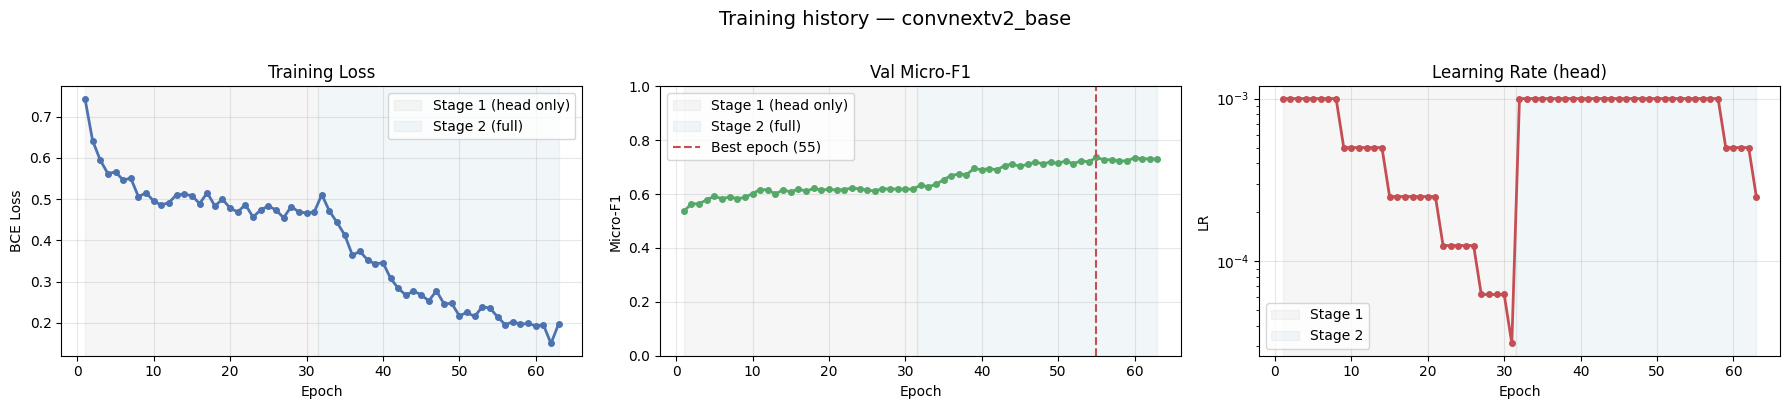

In [32]:
total_epochs = len(history['train_loss'])
s1_end       = history['stage1_end']
ep           = range(1, total_epochs + 1)
best_ep      = int(np.argmax(history['val_f1'])) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(ep, history['train_loss'], marker='o', color='#4C72B0', linewidth=2, markersize=4)
axes[0].axvspan(1,        s1_end + 0.5,   alpha=0.07, color='gray',      label='Stage 1 (head only)')
axes[0].axvspan(s1_end + 0.5, total_epochs, alpha=0.07, color='steelblue', label='Stage 2 (full)')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_f1'], marker='o', color='#55A868', linewidth=2, markersize=4)
axes[1].axvspan(1,        s1_end + 0.5,   alpha=0.07, color='gray',      label='Stage 1 (head only)')
axes[1].axvspan(s1_end + 0.5, total_epochs, alpha=0.07, color='steelblue', label='Stage 2 (full)')
axes[1].axvline(best_ep, color='#C44E52', ls='--', lw=1.5, label=f'Best epoch ({best_ep})')
axes[1].set_title('Val Micro-F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Micro-F1')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['lr'], marker='o', color='#C44E52', linewidth=2, markersize=4)
axes[2].axvspan(1,        s1_end + 0.5,   alpha=0.07, color='gray',      label='Stage 1')
axes[2].axvspan(s1_end + 0.5, total_epochs, alpha=0.07, color='steelblue', label='Stage 2')
axes[2].set_title('Learning Rate (head)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f'Training history — {CONFIG["model_name"]}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Best threshold: 0.43  →  val micro-F1: 0.7391


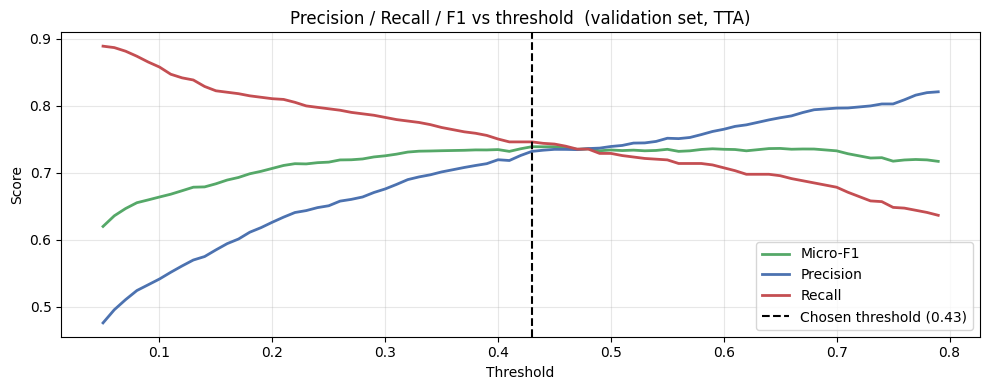

In [33]:
ckpt = torch.load(CONFIG['checkpoint_path'], map_location=CONFIG['device'], weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])

val_probs   = infer_tta(val_dataset, model, CONFIG['device'])
val_targets = np.vstack([y.numpy() for _, y in DataLoader(val_dataset, batch_size=len(val_dataset))])

thresholds = np.arange(0.05, 0.80, 0.01)
all_preds  = val_probs[None] >= thresholds[:, None, None]
f1s   = [f1_score(val_targets, p, average='micro', zero_division=0) for p in all_preds]
precs = [precision_score(val_targets, p, average='micro', zero_division=0) for p in all_preds]
recs  = [recall_score(val_targets, p, average='micro', zero_division=0) for p in all_preds]

best_idx            = int(np.argmax(f1s))
CONFIG['threshold'] = round(float(thresholds[best_idx]), 2)
print(f'Best threshold: {CONFIG["threshold"]}  →  val micro-F1: {f1s[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1s,   label='Micro-F1',  color='#55A868', linewidth=2)
ax.plot(thresholds, precs, label='Precision', color='#4C72B0', linewidth=2)
ax.plot(thresholds, recs,  label='Recall',    color='#C44E52', linewidth=2)
ax.axvline(CONFIG['threshold'], color='black', ls='--', lw=1.5,
           label=f'Chosen threshold ({CONFIG["threshold"]})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs threshold  (validation set, TTA)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

In [34]:
ckpt = torch.load(CONFIG['checkpoint_path'], map_location=CONFIG['device'], weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])

test_probs   = infer_tta(test_dataset, model, CONFIG['device'])
test_preds   = (test_probs >= CONFIG['threshold']).astype(int)
test_targets = np.vstack([y.numpy().astype(int) for _, y in DataLoader(test_dataset, batch_size=len(test_dataset))])

micro_f1 = f1_score(test_targets, test_preds, average='micro', zero_division=0)
macro_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)
print(f'Micro-F1: {micro_f1:.4f}')
print(f'Macro-F1: {macro_f1:.4f}')
print()
print(classification_report(test_targets, test_preds, target_names=CLASS_NAMES, zero_division=0))

Micro-F1: 0.6793
Macro-F1: 0.5259

              precision    recall  f1-score   support

      jacket       0.53      0.51      0.52       108
        coat       0.64      0.66      0.65        93
      blazer       0.60      0.67      0.63        48
      hoodie       0.29      0.27      0.28        15
     sweater       0.40      0.47      0.43        45
     t-shirt       0.57      0.50      0.53        68
       shirt       0.62      0.58      0.60       115
         top       0.59      0.71      0.64       285
       jeans       0.63      0.77      0.69        79
    trousers       0.73      0.84      0.78       210
      shorts       0.79      0.70      0.75        98
       skirt       0.61      0.65      0.63       140
       dress       0.86      0.87      0.86       400
    jumpsuit       0.00      0.00      0.00         9
    sneakers       0.58      0.30      0.39        37
       boots       0.60      0.77      0.68       111
       heels       0.82      0.81      0.81   

## Inference

## Metrics Visualizations

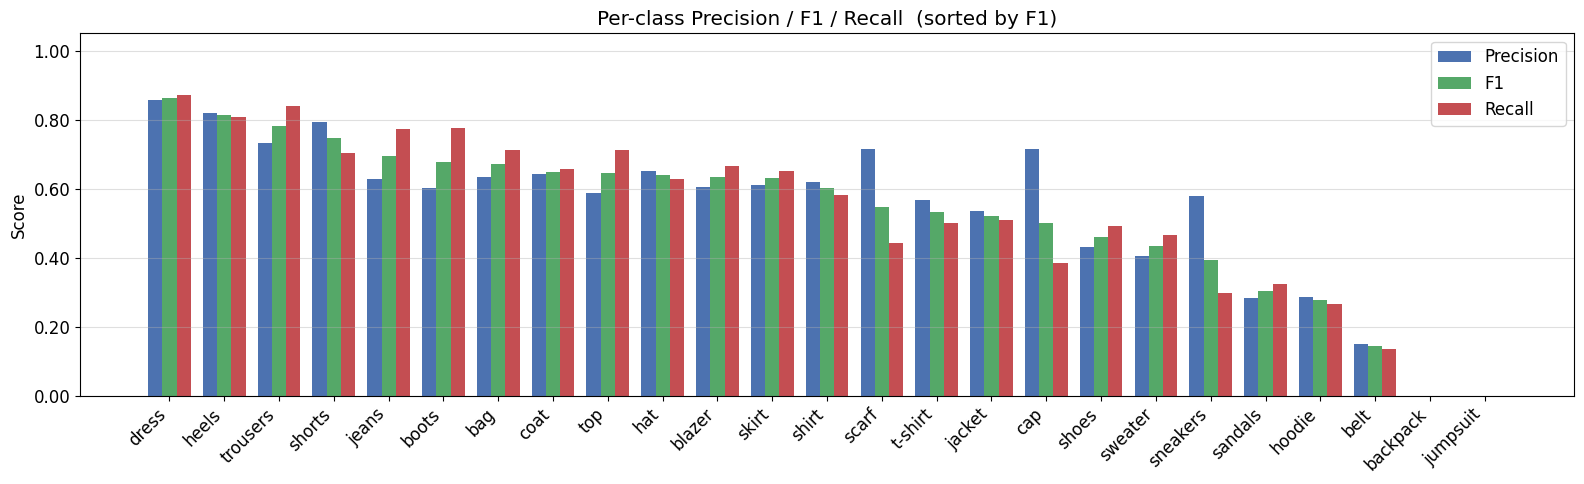

In [35]:
plt.rcParams.update({'font.size': 12})

per_class_p  = precision_score(test_targets, test_preds, average=None, zero_division=0)
per_class_r  = recall_score(test_targets,    test_preds, average=None, zero_division=0)
per_class_f1 = f1_score(test_targets,        test_preds, average=None, zero_division=0)

order = np.argsort(per_class_f1)[::-1]
names_sorted = [CLASS_NAMES[i] for i in order]
p_sorted  = per_class_p[order]
r_sorted  = per_class_r[order]
f1_sorted = per_class_f1[order]

x = np.arange(len(CLASS_NAMES))
w = 0.26

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w, p_sorted,  w, label='Precision', color='#4C72B0')
ax.bar(x,     f1_sorted, w, label='F1',        color='#55A868')
ax.bar(x + w, r_sorted,  w, label='Recall',    color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(names_sorted, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-class Precision / F1 / Recall  (sorted by F1)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

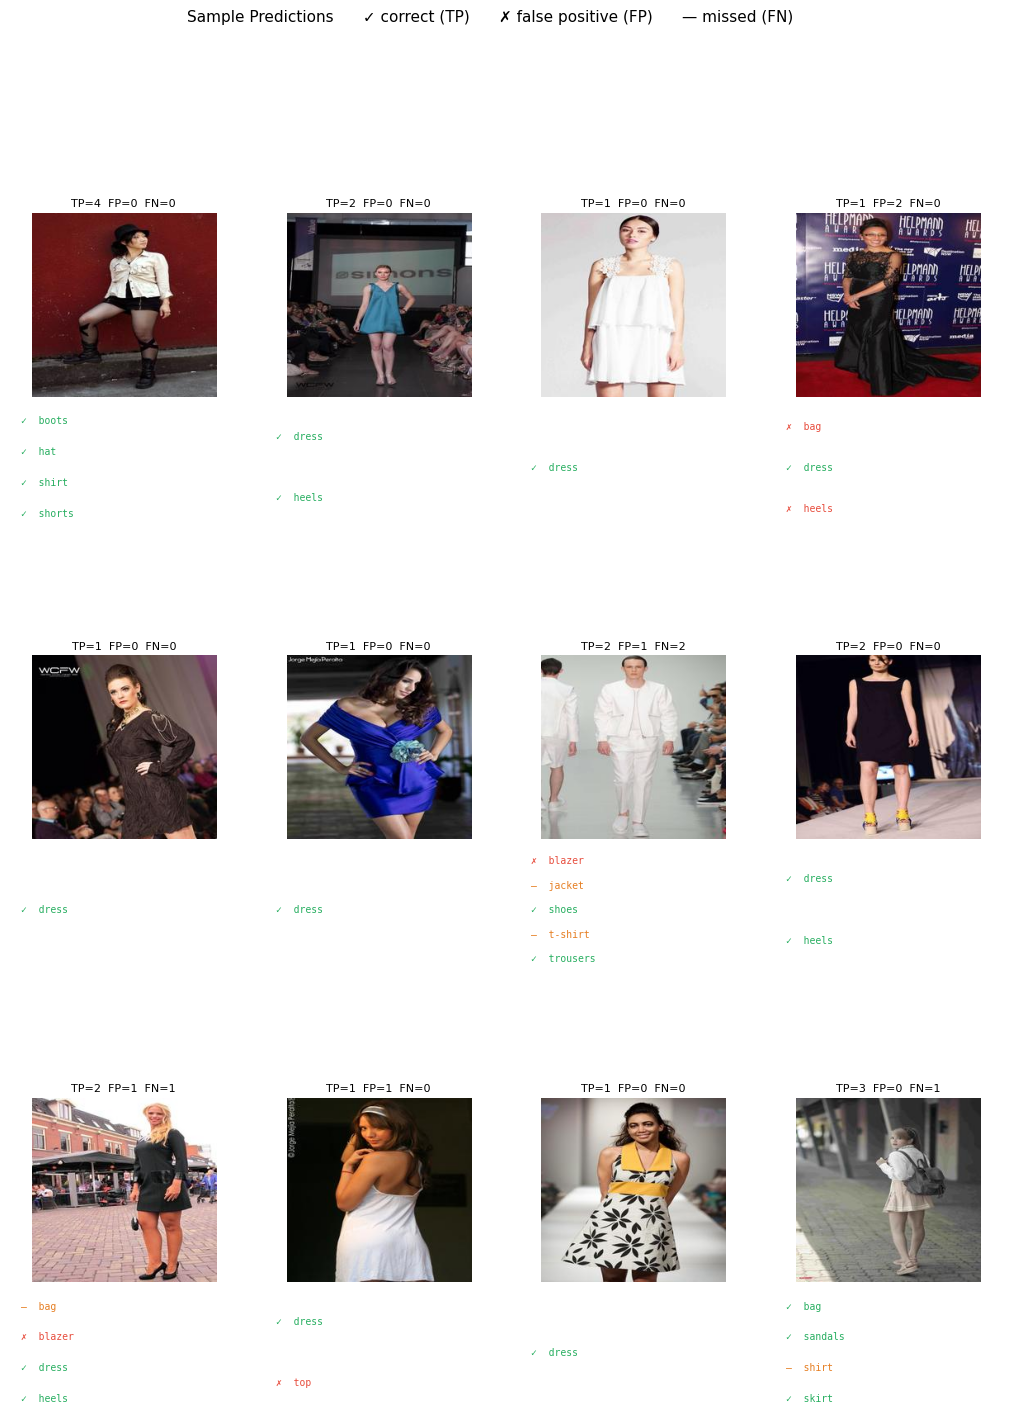

In [39]:
def plot_predictions_grid(dataset, model, class_names, threshold, device, n=12, cols=4, seed=42):
    rng  = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    rows = (len(idxs) + cols - 1) // cols

    fig = plt.figure(figsize=(cols * 3.2, rows * 5.2))
    gs  = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.4, wspace=0.12)
    model.eval()

    for k, ds_idx in enumerate(idxs):
        inner  = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=gs[k // cols, k % cols],
            height_ratios=[3, 2], hspace=0.06,
        )
        img_ax = fig.add_subplot(inner[0])
        lbl_ax = fig.add_subplot(inner[1])

        row_data = dataset.df.iloc[int(ds_idx)]
        image    = Image.open(os.path.join(dataset.image_dir, row_data['image_path'])).convert('RGB')

        with torch.no_grad():
            batch = torch.stack([tfm(image) for tfm in tta_transforms]).to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda', enabled=_use_cuda):
                probs = torch.sigmoid(model(batch)).mean(0).cpu().numpy()

        pred_set = {name for name, p in zip(class_names, probs) if p >= threshold}
        true_set = {name for name in class_names if row_data[name] == 1}

        img_ax.imshow(image)
        img_ax.axis('off')

        tp = len(true_set & pred_set)
        fp = len(pred_set - true_set)
        fn = len(true_set - pred_set)
        img_ax.set_title(f'TP={tp}  FP={fp}  FN={fn}', fontsize=8, pad=4)

        labels = []
        for name in sorted(true_set | pred_set):
            if name in true_set and name in pred_set:
                labels.append((f'✓  {name}', '#27ae60'))
            elif name in pred_set:
                labels.append((f'✗  {name}', '#e74c3c'))
            else:
                labels.append((f'—  {name}', '#e67e22'))

        lbl_ax.axis('off')
        lbl_ax.set_xlim(0, 1)
        lbl_ax.set_ylim(0, 1)
        n_lbl = max(len(labels), 1)
        for i, (text, color) in enumerate(labels):
            y = 1.0 - (i + 0.5) / n_lbl
            lbl_ax.text(0.05, y, text, color=color, va='center',
                        fontsize=7, fontfamily='monospace', clip_on=True)

    plt.suptitle(
        'Sample Predictions      ✓ correct (TP)      ✗ false positive (FP)      — missed (FN)',
        fontsize=11, y=1.01,
    )
    plt.show()

plot_predictions_grid(test_dataset, model, CLASS_NAMES, CONFIG['threshold'], CONFIG['device'])

Prediction:   {'t-shirt': 0.6284, 'dress': 0.521, 'sandals': 0.5146, 'shoes': 0.4836}
Ground truth: {'heels', 'top', 'shorts'}


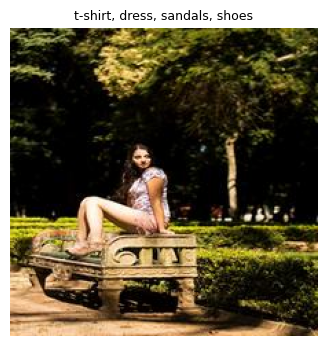

In [36]:
def predict(image_path, model, class_names, threshold, device):
    image = Image.open(image_path).convert('RGB').resize((224, 224), Image.LANCZOS)
    model.eval()
    with torch.no_grad():
        batch = torch.stack([tfm(image) for tfm in tta_transforms]).to(device, non_blocking=True)
        with torch.amp.autocast(device_type='cuda', enabled=_use_cuda):
            probs = torch.sigmoid(model(batch)).mean(0).cpu().numpy()
    return {name: round(float(p), 4) for name, p in zip(class_names, probs) if p >= threshold}

sample_row  = test_df.sample(1, random_state=0).iloc[0]
sample_path = os.path.join(CONFIG['test_images_dir'], sample_row['image_path'])

result       = predict(sample_path, model, CLASS_NAMES, CONFIG['threshold'], CONFIG['device'])
ground_truth = {c for c in CLASS_NAMES if sample_row[c] == 1}

print('Prediction:  ', result)
print('Ground truth:', ground_truth)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(Image.open(sample_path))
ax.set_title(', '.join(result.keys()) or 'none', fontsize=9)
ax.axis('off')
plt.show()